# Notebook 11 — Del in Polar Coordinates

Every notebook so far has stayed in Cartesian $(x, y)$, where $\nabla =
(\partial_x, \partial_y)$ has no hidden extra factors, because the
Cartesian basis vectors $\hat{x}$ and $\hat{y}$ point the same direction
everywhere. Switch to polar $(r, \theta)$ and that stops being true: the
radial and angular basis vectors $\hat{r}$, $\hat{\theta}$ rotate as you
move around the plane. That single fact is the entire reason polar
formulas for gradient, divergence, and curl look more complicated than
their Cartesian counterparts — not new physics, just bookkeeping for
basis vectors that don't sit still.

In [1]:
# Make src/ importable from inside notebooks/
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
%matplotlib inline

from src import operators as ops


## 1. By hand

A step $dr$ in the radial direction covers physical distance $dr$ — same
as Cartesian. But a step $d\theta$ in the angular direction covers
physical distance $r\,d\theta$, not $d\theta$: the further out you are,
the more ground the same angular step covers. That's where every $1/r$ in
the formulas below comes from — each one is converting an angular
derivative back into a *physical* rate of change.

$$\nabla f = \frac{\partial f}{\partial r}\,\hat{r} + \frac{1}{r}\frac{\partial f}{\partial\theta}\,\hat{\theta}$$

$$\nabla\cdot\mathbf{F} = \frac{1}{r}\frac{\partial (r F_r)}{\partial r} + \frac{1}{r}\frac{\partial F_\theta}{\partial\theta}$$

$$(\nabla\times\mathbf{F})_z = \frac{1}{r}\left[\frac{\partial (r F_\theta)}{\partial r} - \frac{\partial F_r}{\partial\theta}\right]$$

The divergence and curl formulas have an *extra* $1/r$ multiplying the
whole $r$-derivative term too, not just the $\theta$-derivative term — that
one isn't about arc length, it's the product rule catching the fact that
$\hat{r}$ itself rotates (and therefore has a nonzero derivative) as
$\theta$ changes, even though $\hat{r}$ doesn't change as $r$ changes.

**Worked example.** Let $f(r,\theta) = r^2\cos(2\theta)$ — this is $x^2-y^2$
in polar clothes, since $r^2\cos(2\theta) = r^2(\cos^2\theta-\sin^2\theta)
= x^2 - y^2$:

- $\partial f/\partial r = 2r\cos(2\theta)$
- $(1/r)\,\partial f/\partial\theta = (1/r)(-2r^2\sin(2\theta)) = -2r\sin(2\theta)$

Section 2 checks this against the known Cartesian answer $\nabla(x^2-y^2)
= (2x, -2y)$ directly, by rotating that Cartesian vector into $\hat r,
\hat\theta$ components and confirming it lands on the same two numbers.

**Worked example (divergence & curl).** Let $F_r = r$, $F_\theta = r$ — in
Cartesian this is $\mathbf{F} = (x-y,\ x+y)$, an outward spiral:

- $\nabla\cdot\mathbf{F} = (1/r)\,\partial(r\cdot r)/\partial r = (1/r)(2r) = 2$
- $(\nabla\times\mathbf{F})_z = (1/r)\,\partial(r\cdot r)/\partial r = (1/r)(2r) = 2$

Both constant, matching $\nabla\cdot(x-y,x+y) = 1+1=2$ and $(\nabla\times
(x-y,x+y))_z = 1-(-1) = 2$ computed directly in Cartesian.

## 2. SymPy verification

Confirm the worked gradient example by two independent routes: differentiate
$f$ directly in polar coordinates, and separately rotate the already-known
Cartesian gradient $(2x,-2y)$ into $\hat r,\hat\theta$ components. They
should agree exactly — this is what the boxed gradient formula in section 1
is actually asserting.

In [2]:
r, theta, x, y = sp.symbols('r theta x y', positive=True)
to_polar = {x: r * sp.cos(theta), y: r * sp.sin(theta)}

f_xy = x**2 - y**2
f_polar = sp.simplify(f_xy.subs(to_polar))
print("f(r, θ) =", f_polar)

df_dr = sp.simplify(sp.diff(f_xy.subs(to_polar), r))
df_dtheta_over_r = sp.simplify(sp.diff(f_xy.subs(to_polar), theta) / r)
print("∂f/∂r        =", df_dr)
print("(1/r) ∂f/∂θ  =", df_dtheta_over_r)

# Independently: rotate the known Cartesian gradient (2x, -2y) into r-hat, theta-hat
grad_x, grad_y = 2 * x, -2 * y
radial_component = sp.simplify((grad_x * sp.cos(theta) + grad_y * sp.sin(theta)).subs(to_polar))
theta_component = sp.simplify((-grad_x * sp.sin(theta) + grad_y * sp.cos(theta)).subs(to_polar))
print("∇f · r-hat     =", radial_component)
print("∇f · theta-hat =", theta_component)

assert sp.simplify(df_dr - radial_component) == 0
assert sp.simplify(df_dtheta_over_r - theta_component) == 0


f(r, θ) = r**2*cos(2*theta)
∂f/∂r        = 2*r*cos(2*theta)
(1/r) ∂f/∂θ  = -2*r*sin(2*theta)
∇f · r-hat     = 2*r*cos(2*theta)
∇f · theta-hat = -2*r*sin(2*theta)


## 3. NumPy on a polar grid

Build a genuine $(r,\theta)$ grid rather than a Cartesian one. Two of its
directions behave differently for finite differences:

- $r$ is an **open** interval (this notebook starts at $r=0.5$ specifically
  to sidestep the $1/r$ singularity at the origin — the metric factors above
  are undefined there, not just numerically inconvenient). One-sided
  differences at its two edges, exactly what `np.gradient` already does, are
  the right call here.
- $\theta$ is **periodic** — same situation notebook 10 ran into. Using
  `np.gradient` for the $\theta$-derivative would silently reintroduce that
  notebook's O(Δx) edge problem, so this uses the same wraparound fix.

In [3]:
def periodic_ddtheta(f, dtheta):
    """Central difference along theta (axis 0) that wraps around -- same
    fix as notebook 10's periodic_ddx, needed here for the same reason.
    """
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dtheta)


def polar_gradient(f, R, dr, dtheta):
    f_r = np.gradient(f, dr, axis=1)
    f_theta = periodic_ddtheta(f, dtheta) / R
    return f_r, f_theta


def polar_divergence(Fr, Ftheta, R, dr, dtheta):
    d_rFr_dr = np.gradient(R * Fr, dr, axis=1)
    dFtheta_dtheta = periodic_ddtheta(Ftheta, dtheta)
    return d_rFr_dr / R + dFtheta_dtheta / R


def polar_curl(Fr, Ftheta, R, dr, dtheta):
    d_rFtheta_dr = np.gradient(R * Ftheta, dr, axis=1)
    dFr_dtheta = periodic_ddtheta(Fr, dtheta)
    return (d_rFtheta_dr - dFr_dtheta) / R


In [4]:
nr, ntheta = 120, 240
r_vals = np.linspace(0.5, 3.0, nr)
theta_vals = np.linspace(0, 2 * np.pi, ntheta, endpoint=False)
R, THETA = np.meshgrid(r_vals, theta_vals)  # shape (ntheta, nr): row = theta, col = r
dr = r_vals[1] - r_vals[0]
dtheta = theta_vals[1] - theta_vals[0]

X = R * np.cos(THETA)
Y = R * np.sin(THETA)

f = R**2 * np.cos(2 * THETA)  # = x^2 - y^2
f_r_num, f_theta_num = polar_gradient(f, R, dr, dtheta)

f_r_exact = 2 * R * np.cos(2 * THETA)
f_theta_exact = -2 * R * np.sin(2 * THETA)

interior_r = slice(2, -2)  # exclude the one-sided r edges; theta has none to exclude
err_r = np.max(np.abs(f_r_num[:, interior_r] - f_r_exact[:, interior_r]))
err_theta = np.max(np.abs(f_theta_num[:, interior_r] - f_theta_exact[:, interior_r]))
print(f"max |∂f/∂r error|          = {err_r:.2e}")
print(f"max |(1/r)∂f/∂θ error|     = {err_theta:.2e}")


max |∂f/∂r error|          = 8.08e-14
max |(1/r)∂f/∂θ error|     = 2.70e-03


In [5]:
Fr = R.copy()
Ftheta = R.copy()

div_num = polar_divergence(Fr, Ftheta, R, dr, dtheta)
curl_num = polar_curl(Fr, Ftheta, R, dr, dtheta)

err_div = np.max(np.abs(div_num[:, interior_r] - 2.0))
err_curl = np.max(np.abs(curl_num[:, interior_r] - 2.0))
print(f"max |∇·F − 2|  = {err_div:.2e}")
print(f"max |(∇×F)_z − 2| = {err_curl:.2e}")


max |∇·F − 2|  = 1.78e-14
max |(∇×F)_z − 2| = 1.78e-14


## 4. Cross-check against Cartesian

The physical gradient vector at a point can't depend on which coordinate
system was used to compute it. Rotate the numerically-computed
$(\partial f/\partial r,\ (1/r)\partial f/\partial\theta)$ at every grid
point into Cartesian $(\partial f/\partial x,\ \partial f/\partial y)$ and
compare directly against the known analytical answer $\nabla(x^2-y^2) =
(2x,-2y)$ — a genuinely independent check, since the analytical formula
was never expressed in polar terms to begin with.

In [6]:
grad_x_num = f_r_num * np.cos(THETA) - f_theta_num * np.sin(THETA)
grad_y_num = f_r_num * np.sin(THETA) + f_theta_num * np.cos(THETA)

grad_x_exact = 2 * X
grad_y_exact = -2 * Y

err_x = np.max(np.abs(grad_x_num[:, interior_r] - grad_x_exact[:, interior_r]))
err_y = np.max(np.abs(grad_y_num[:, interior_r] - grad_y_exact[:, interior_r]))
print(f"max |∇f_x (polar, rotated) − 2x| = {err_x:.2e}")
print(f"max |∇f_y (polar, rotated) − (−2y)| = {err_y:.2e}")


max |∇f_x (polar, rotated) − 2x| = 2.08e-03
max |∇f_y (polar, rotated) − (−2y)| = 2.08e-03


## 5. Visualization

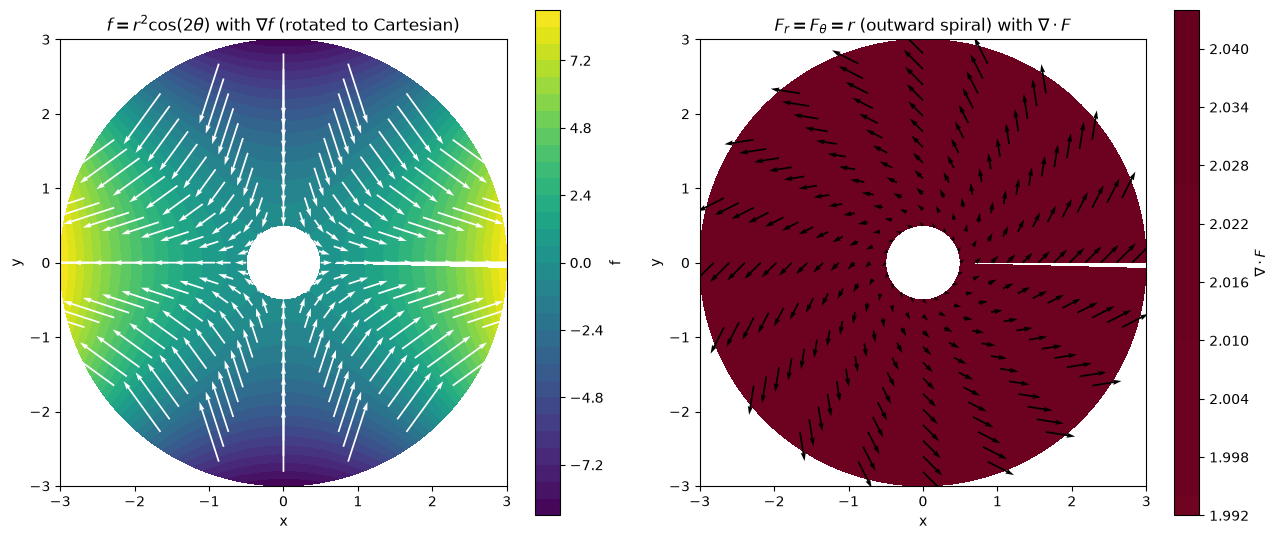

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

c0 = axes[0].contourf(X, Y, f, levels=30, cmap="viridis")
fig.colorbar(c0, ax=axes[0], label="f")
step_t, step_r = 12, 10
sl = (slice(None, None, step_t), slice(None, None, step_r))
axes[0].quiver(X[sl], Y[sl], grad_x_num[sl], grad_y_num[sl], color="white", scale=40)
axes[0].set_title(r"$f = r^2\cos(2\theta)$ with $\nabla f$ (rotated to Cartesian)")
axes[0].set_aspect("equal")

Fx = Fr * np.cos(THETA) - Ftheta * np.sin(THETA)
Fy = Fr * np.sin(THETA) + Ftheta * np.cos(THETA)
vmax = np.max(np.abs(div_num))
c1 = axes[1].contourf(X, Y, div_num, levels=30, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
fig.colorbar(c1, ax=axes[1], label=r"$\nabla\cdot F$")
# streamplot needs a rectilinear grid; this one is polar-mapped, so quiver instead
axes[1].quiver(X[sl], Y[sl], Fx[sl], Fy[sl], color="black", scale=60)
axes[1].set_title(r"$F_r=F_\theta=r$ (outward spiral) with $\nabla\cdot F$")
axes[1].set_aspect("equal")

for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")

fig.tight_layout()
plt.show()


**Reading this.** Both panels are plotted in ordinary $(x,y)$ — the
polar grid was only used *internally*, for the derivatives — since
$X=R\cos\Theta$, $Y=R\sin\Theta$ turns the polar mesh into the familiar
annular wedge shape. The gradient arrows in the left panel are already
converted to Cartesian components (section 4), which is why they can sit
directly on a normal Cartesian plot rather than needing a special polar
quiver.

The right panel's constant `∇·F = 2` (uniform color) is worth comparing to
the radial-source examples in notebook 02 — divergence-2 there came from
$F=(x,y)$ pointing straight outward; here $F_r=F_\theta=r$ points outward
*and* rotates, and the divergence is still exactly 2, unaffected by the
rotational part (which is what curl, not divergence, is built to measure).

## 6. Exercise

Cylindrical coordinates $(r, \\theta, z)$ are polar-plus-a-plain-Cartesian-
axis: nothing in the $z$-direction gets a metric factor, since a step $dz$
covers physical distance $dz$ regardless of $r$. Divergence becomes

$$\\nabla\\cdot\\mathbf{F} = \\frac{1}{r}\\frac{\\partial(rF_r)}{\\partial r} + \\frac{1}{r}\\frac{\\partial F_\\theta}{\\partial\\theta} + \\frac{\\partial F_z}{\\partial z}$$

Extend `polar_divergence` into a `cylindrical_divergence(Fr, Ftheta, Fz, R,
dr, dtheta, dz)` (the $z$-derivative is just `np.gradient(Fz, dz, axis=2)`
on a 3D $(r,\\theta,z)$ grid shaped like this notebook's, with a $z$ axis
appended). Test it on $F_r = r,\\ F_\\theta = r,\\ F_z = z$ and confirm you
get the constant $3$ — the same $2$ from this notebook's spiral field, plus
$\\partial z/\\partial z = 1$ from the new axis.


In [8]:
# Your answer here.
# def cylindrical_divergence(Fr, Ftheta, Fz, R, dr, dtheta, dz):
#     ...
